# 1D Signal Decomposition (Time-Series)

Decompose 1-D signals into topologically meaningful basis components using **Top-NMF**.

- **Part A** -- Periodic vs non-periodic separation (Vietoris-Rips persistence via time-delay embedding)
- **Part B** -- Unimodal basis (1-D cubical persistence)

## Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import torch
from scipy.interpolate import make_interp_spline

from TopNMF import (
    TopologicalNMF,
    CubicalComplex,
    weighted_persistence_loss,
    compute_periodicity_score,
)
from TopNMF.visualization import FitMonitor

device = "cpu"

---
## Part A: Periodic vs non-periodic separation (Vietoris-Rips)

Use time-delay embedding to lift 1-D signals into a point cloud, then apply Vietoris-Rips persistence to separate periodic from non-periodic components.

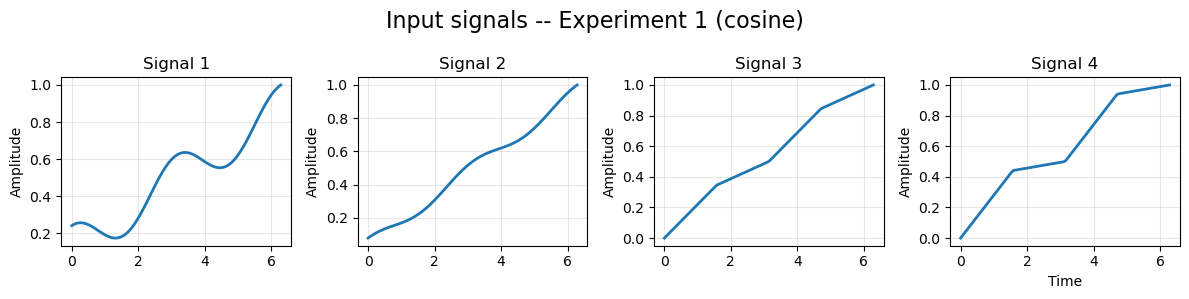

In [3]:
import scipy.signal as signal

np.random.seed(42)
t = np.linspace(0, 2 * np.pi, 100)

gt_basis = [np.cos(2 * t) + 1, signal.sawtooth(2 * t, 0.5)+1, t]

n_components = 3
X = np.vstack([gt_basis[0] + gt_basis[2],  0.8 * gt_basis[0] + 3 * gt_basis[2],
                  0.3 * gt_basis[1] + gt_basis[2], 1.2 * gt_basis[1] + 2 * gt_basis[2] ])
X = X / np.max(np.abs(X), axis=1, keepdims=True)

num_signals = len(X)

fig, axes = plt.subplots(1, num_signals, figsize=(3*num_signals, 3))
fig.suptitle("Input signals -- Experiment 1 (cosine)", fontsize=16)
for i, ax in enumerate(axes):
    ax.plot(t, X[i], linewidth=2, color="tab:blue")
    ax.set_title(f"Signal {i + 1}")
    ax.grid(alpha=0.3)
    ax.set_ylabel("Amplitude")
axes[-1].set_xlabel("Time")
plt.tight_layout()
plt.show()

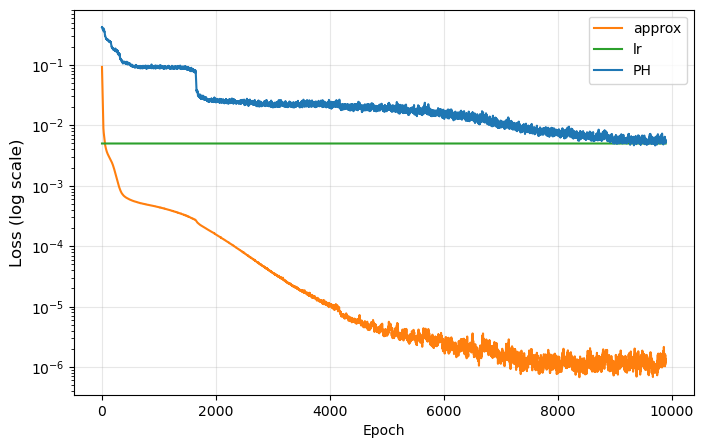

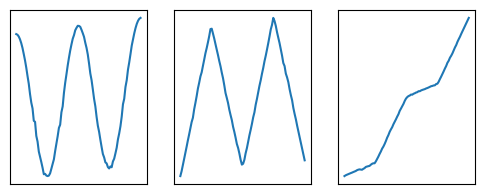

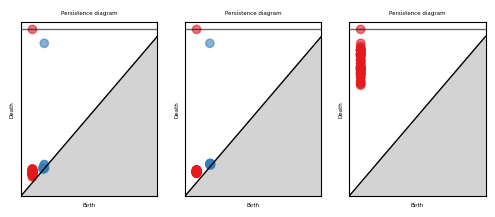

  0%|          | 0/10000 [00:00<?, ?it/s]

In [4]:
n_components = 3

# target_periodicity=[1.0, 1.0, None] forces the first two bases to be periodic
target_periodicity=[1.0, 1.0, None]

model_cos = TopologicalNMF(
    n_components=n_components,
    device=device,
    random_state=42,
    use_embedding=True,
)

monitor_cos = FitMonitor(
    show=["loss", "basis", "PH"],
    interval=10,
    grid=(1, n_components),
)

model_cos.fit(
    X,
    n_iterations=10000,
    lr=0.005,
    lambda_apx=1.0,
    lambda_top=0.0005,
    target_periodicity=target_periodicity,
    start_epoch_topological=0,
    embedding_dim=4,
    init_method="nndsvda",
    verbose=True,
    monitor=monitor_cos,
)

plt.close("all")

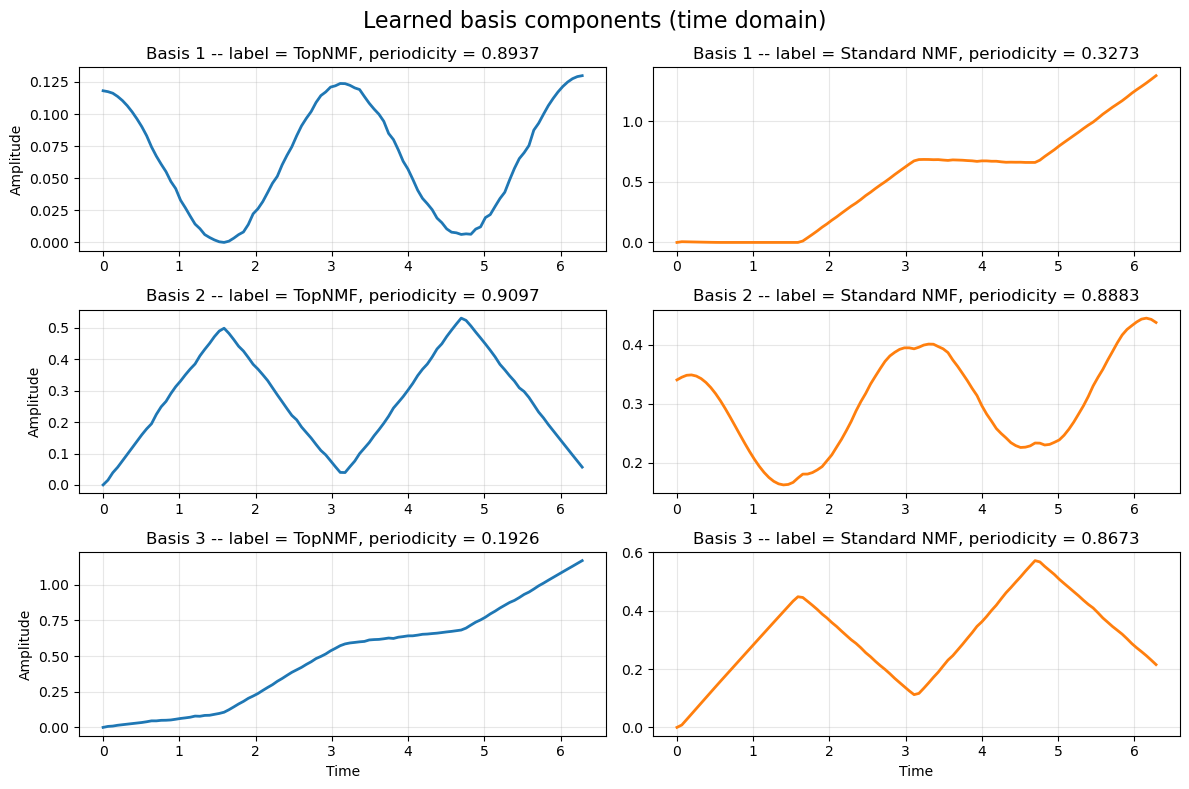

In [5]:
# Learned basis components in the time domain
from sklearn.decomposition import NMF

fig, axes = plt.subplots(n_components, 2, figsize=(12, 8))
fig.suptitle("Learned basis components (time domain)", fontsize=16)

V_top = model_cos.get_components()
W = model_cos.transform(X)
X_recon = model_cos.inverse_transform()

nmf = NMF(n_components=n_components, init="random", random_state=43)
W_nmf = nmf.fit_transform(X)
V_nmf = nmf.components_

# Periodicity score: 1 = perfectly periodic, 0 = non-periodic
embedding_dim = 4
tau = int(len(t) / (2 * (embedding_dim + 1)))

for row, (V, color, label) in enumerate(
    [(V_top, "tab:blue", "TopNMF"), (V_nmf, "tab:orange", "Standard NMF")]
):
    for col in range(n_components):
        ax = axes[col, row]
        ax.plot(t, V[col], linewidth=2, color=color)
        score = compute_periodicity_score(V[col], dim=embedding_dim + 1, tau=tau)
        ax.set_title(f"Basis {col + 1} -- label = {label}, periodicity = {score:.4f}")
        ax.grid(alpha=0.3)
        if row == 0:
            ax.set_ylabel("Amplitude")
        if col == n_components - 1:
            ax.set_xlabel("Time")

plt.tight_layout()
plt.show()

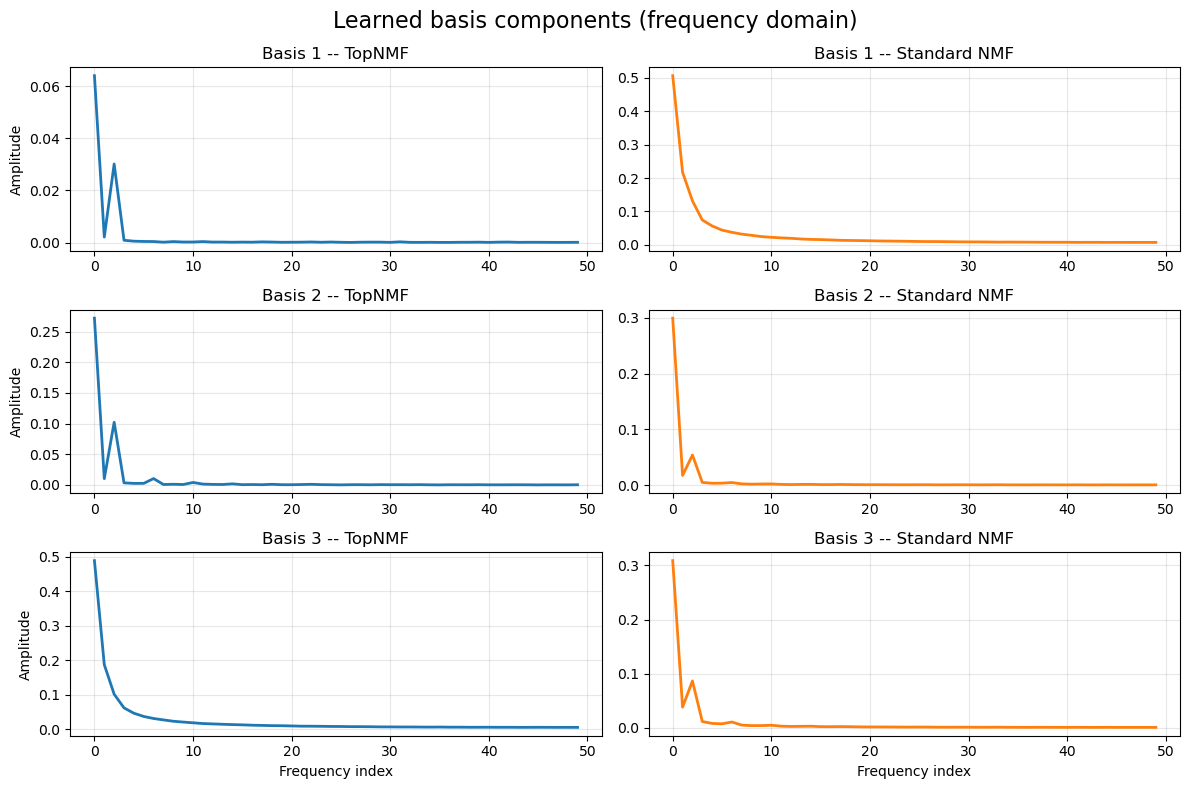

In [6]:
# Fourier spectra of the learned basis components
n_freq = 50

fig, axes = plt.subplots(n_components, 2, figsize=(12, 8))
fig.suptitle("Learned basis components (frequency domain)", fontsize=16)

for row, (V, color, label) in enumerate(
    [(V_top, "tab:blue", "TopNMF"), (V_nmf, "tab:orange", "Standard NMF")]
):
        for col in range(n_components):
            spectrum = np.abs(np.fft.fft(V[col]))[:n_freq] / len(V[col])
            ax = axes[col, row]
            ax.plot(spectrum, linewidth=2, color=color)
            ax.set_title(f"Basis {col + 1} -- {label}")
            ax.grid(alpha=0.3)
            if row == 0:
                ax.set_ylabel("Amplitude")
            if col == n_components - 1:
                ax.set_xlabel("Frequency index")

plt.tight_layout()
plt.show()

---
## Part B: Unimodal basis

### Construct synthetic signals

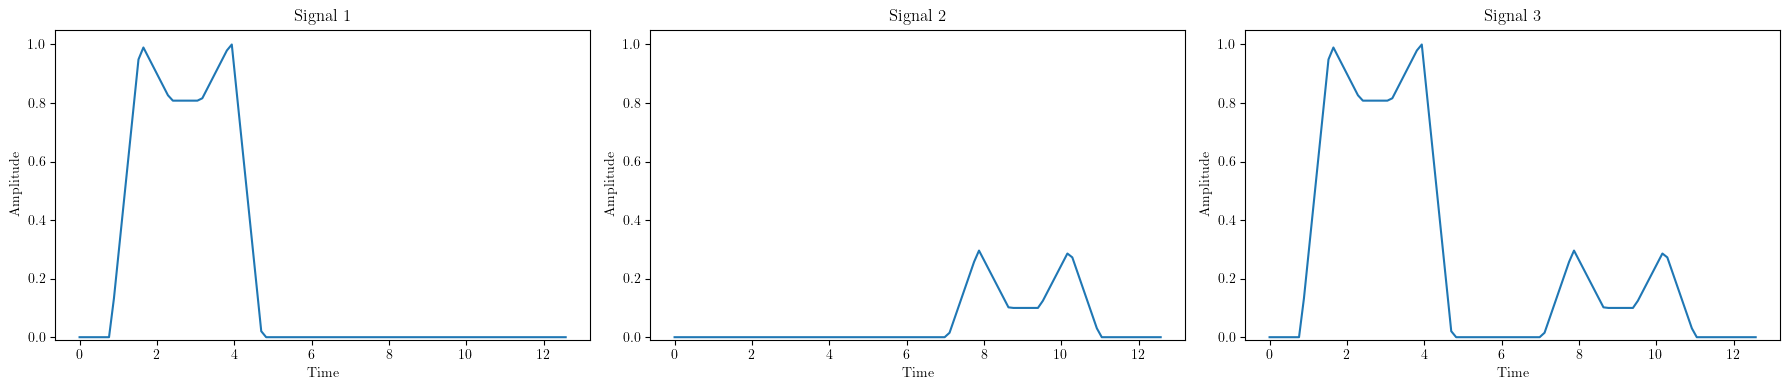

In [15]:
# Anchor points for piecewise-linear interpolation
x_anchor = np.arange(17, dtype=float)
a_smooth = np.linspace(x_anchor.min(), x_anchor.max(), 100)

# Shape 1: a bump in the first third
y1_anchor = np.array([0, 0, 1, 0.8, 0.8, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
y_smooth_1 = make_interp_spline(x_anchor, y1_anchor, k=1)(a_smooth)
y_smooth_1 /= y_smooth_1.max()

# Shape 2: a smaller bump in the second third
y2_anchor = np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.3, 0.1, 0.1, 0.3, 0, 0, 0])
y_smooth_2 = make_interp_spline(x_anchor, y2_anchor, k=1)(a_smooth)

# Dataset: two pure shapes + their sum
X_pwl = np.array([y_smooth_1, y_smooth_2, y_smooth_1 + y_smooth_2])

t_pwl = np.linspace(0, 4 * np.pi, 100)
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for i, ax in enumerate(axes):
    ax.plot(t_pwl, X_pwl[i])
    ax.set_xlabel("Time")
    ax.set_ylabel("Amplitude")
    ax.set_ylim(-0.01, 1.05)
    ax.set_title(f"Signal {i + 1}")
plt.tight_layout()
plt.show()

### Fit Top-NMF with 1-D cubical persistence

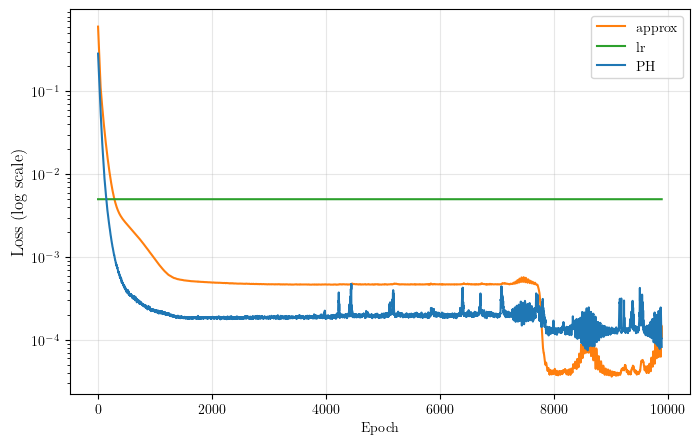

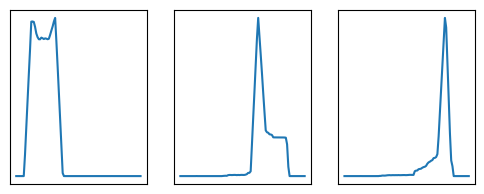

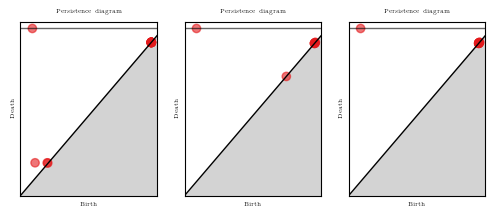

  0%|          | 0/10000 [00:00<?, ?it/s]

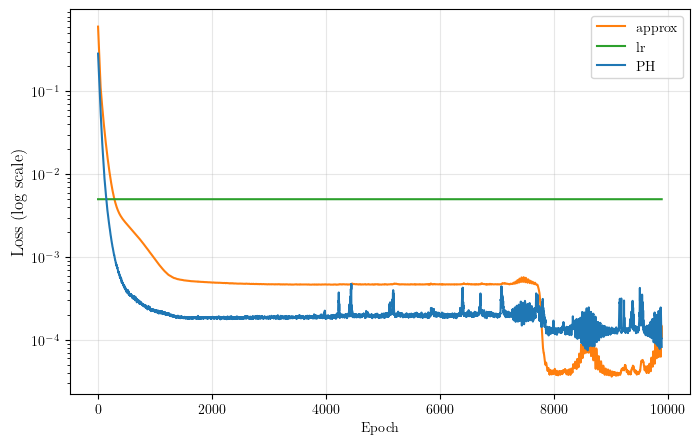

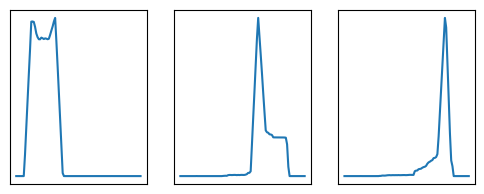

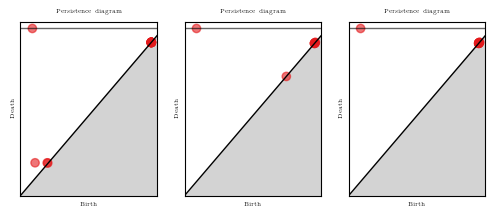

In [17]:
# Superlevel vertex-based cubical complex for 1-D signals
cubical_pwl = CubicalComplex(
    superlevel=True,
    dim=len((X_pwl.shape[1],)),
    mode="V",
)

# Empty target diagrams penalise all persistent features
target_diagrams_pwl = [
    torch.tensor([[]], dtype=torch.float, device=device),
    torch.tensor([[]], dtype=torch.float, device=device),
]

model_pwl = TopologicalNMF(
    n_components=3,
    device=device,
    complex=cubical_pwl,
    ph_loss_fn=weighted_persistence_loss,
    ph_loss_params={"remove_longest": False},
    data_shape=(X_pwl.shape[1],),
    use_embedding=False,
    random_state=42,
)

monitor_pwl = FitMonitor(
    show=["loss", "basis", "PH"],
    interval=10,
    grid=(1, 3),
    PHmode="V",
    superlevel=True,
)

model_pwl.fit(
    X_pwl,
    n_iterations=10000,
    lr=0.005,
    lambda_top=0.5,
    PH_dims=[0],
    verbose=True,
    init_method="nndsvda",
    target_diagrams=target_diagrams_pwl,
    normalize_V_max=True,
    monitor=monitor_pwl,
)

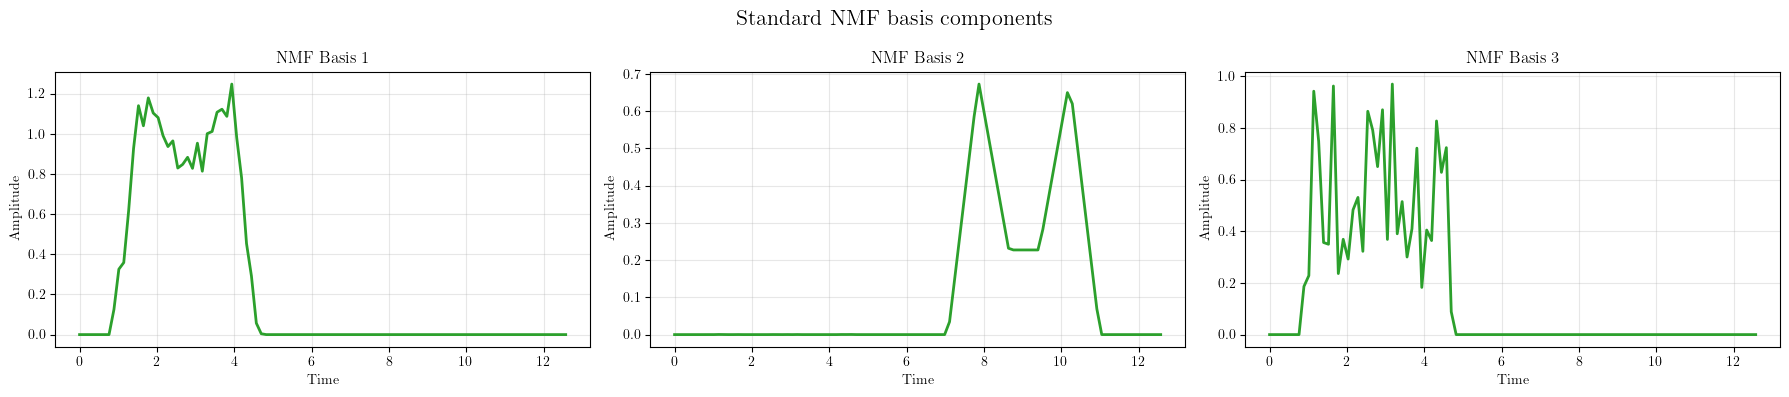

In [18]:
# Standard NMF for comparison with Part B (unimodal basis)
nmf_pwl = NMF(n_components=3, init='random', random_state=42)
W_pwl_nmf = nmf_pwl.fit_transform(X_pwl)
H_pwl_nmf = nmf_pwl.components_

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle("Standard NMF basis components", fontsize=16)

for i, ax in enumerate(axes):
    ax.plot(t_pwl, H_pwl_nmf[i], linewidth=2, color="tab:green")
    ax.set_xlabel("Time")
    ax.set_ylabel("Amplitude")
    ax.set_title(f"NMF Basis {i + 1}")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()